# 3C-FBI: Combinatorial Convolutions for Circle Fitting in Blurry Images

This notebook is a step-by-step educational version of `algorithms/CCC_FBI.py`.
It re-implements the 3C-FBI algorithm cell by cell so each step can be inspected and visualised.

**Algorithm overview (5 steps)**

1. **Edgel extraction** — receive the set of edge points $E$.
2. **Triplet sampling, circle fitting, filtering** — sample $N_{\mathrm{tri}}$ random triplets, fit a circle to each, discard collinear/out-of-bounds/out-of-radius candidates, round and vote in an integer accumulator $V$.
3. **Top-$N$ peak selection** — keep the $N$ most-voted cells of $V$.
4. **Candidate expansion + convolutional scoring** — expand each peak to its $3\times3\times3$ neighbourhood, score every candidate by summing top-$N$ peak weights inside a cubic window of half-width $\tau$.
5. **Final estimate** — pick $\arg\max_c S(c)$ and return its weighted centroid.

Triplet filtering matches CIBICA exactly: $D=0$ collinearity, symmetric $\pm 20$ px center bounds, radius range $[r_{\min}, r_{\max}]$.

## Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

rng = np.random.default_rng(0)
random.seed(0)

## Step 2 helper — `vectorized_XYR`

Fits circumscribed circles through batches of triplets and applies the three CIBICA-equivalent filters:

1. **Collinearity** — discard if $D = 0$ (exact zero).
2. **Center bounds** — discard if center lies outside $[-20,\,x_{\max}+20] \times [-20,\,y_{\max}+20]$.
3. **Radius range** — discard if $r < r_{\min}$ or $r > r_{\max}$ (defaults 4 and 30 px, matching CIBICA).

In [2]:
def vectorized_XYR(p1, p2, p3, xmax=50, ymax=50, rmin=4, rmax=30, minval=-20):
    """Fit circles through triplets and apply the three CIBICA filters."""
    temp = p2[:, 0] ** 2 + p2[:, 1] ** 2
    bc   = (p1[:, 0] ** 2 + p1[:, 1] ** 2 - temp) / 2
    cd   = (temp - p3[:, 0] ** 2 - p3[:, 1] ** 2) / 2
    det  = (p1[:, 0] - p2[:, 0]) * (p2[:, 1] - p3[:, 1]) - \
           (p2[:, 0] - p3[:, 0]) * (p1[:, 1] - p2[:, 1])

    # Filter 1 — collinearity (exact zero)
    mask = det != 0
    if not np.any(mask):
        return np.array([]), np.array([]), np.array([])

    cx = np.zeros_like(det)
    cy = np.zeros_like(det)
    cx[mask] = (bc[mask] * (p2[mask, 1] - p3[mask, 1])
                - cd[mask] * (p1[mask, 1] - p2[mask, 1])) / det[mask]
    cy[mask] = ((p1[mask, 0] - p2[mask, 0]) * cd[mask]
                - (p2[mask, 0] - p3[mask, 0]) * bc[mask]) / det[mask]

    # Filter 2 — center bounds (symmetric ±20)
    mask &= (cx >= minval) & (cy >= minval)
    mask &= (cx <= xmax + 20) & (cy <= ymax + 20)
    if not np.any(mask):
        return np.array([]), np.array([]), np.array([])

    radius = np.zeros_like(det)
    radius[mask] = np.sqrt((cx[mask] - p1[mask, 0]) ** 2
                           + (cy[mask] - p1[mask, 1]) ** 2)

    # Filter 3 — radius range
    mask &= (radius >= rmin) & (radius <= rmax)
    return cx[mask], cy[mask], radius[mask]

## Step 3 helper — `find_top_3d_modes`

After rounding the surviving $(x, y, r)$ to integer cells, find the $N$ most frequent integer triplets.
Ties are broken by first-occurrence order (`Counter.most_common` behaviour).

In [3]:
def find_top_3d_modes(points, top_n=5):
    """Return the top-N most frequent integer (x, y, r) tuples and their counts."""
    most_common = Counter(map(tuple, points)).most_common(top_n)
    if not most_common:
        return [], []
    points_list, frequencies_list = zip(*most_common)
    return list(points_list), list(frequencies_list)

## Step 4a helper — `add_neighboring_points`

Expand each top peak $p_i$ to its $3\times3\times3$ neighbourhood:
$\mathcal{C} = \mathcal{P} \cup \{p_i + \delta : \delta \in \{-1, 0, 1\}^3\}$.
Duplicates are discarded so the same candidate is only scored once.

In [4]:
def add_neighboring_points(points):
    """Return points ∪ their 3×3×3 neighbours (deduplicated)."""
    points = points.tolist()
    points_set = {tuple(p) for p in points}
    neighbors = []
    for x, y, z in points:
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for dz in (-1, 0, 1):
                    new_point = (x + dx, y + dy, z + dz)
                    if new_point not in points_set:
                        neighbors.append(new_point)
                        points_set.add(new_point)
    return np.array(points + neighbors)

## Step 4b helper — `conv3D_sum`

For a single candidate $c = (x_0, y_0, z_0)$, walk the cubic window of half-width $\tau$ around it inside the sparse voting volume $V$ and accumulate two quantities at once:

- **score** $S(c) = \sum_{q \in W_\tau(c)} V[q]$ — total vote mass inside the window.
- **centroid** $\mu(c) = \dfrac{1}{S(c)} \sum_{q \in W_\tau(c)} q \cdot V[q]$ — value-weighted center of mass.

Out-of-bounds cells are skipped silently. If the window contains no votes, the function returns score $= 0$ and the input point itself.

*This is the pure-Python form of `conv3D_sum_numba`. Drop in `@numba.jit(nopython=True)` for the production speed.*

In [5]:
def conv3D_sum(data_volume, x0, y0, z0, tol=1):
    """Boxcar convolution score + weighted centroid at (x0, y0, z0)."""
    total_sum = 0.0
    weighted_sum = np.zeros(3)
    nx, ny, nz = data_volume.shape
    for dx in range(-tol, tol + 1):
        for dy in range(-tol, tol + 1):
            for dz in range(-tol, tol + 1):
                x, y, z = x0 + dx, y0 + dy, z0 + dz
                if 0 <= x < nx and 0 <= y < ny and 0 <= z < nz:
                    value = data_volume[x, y, z]
                    total_sum += value
                    weighted_sum += np.array([x, y, z]) * value
    if total_sum > 0:
        return total_sum, tuple(weighted_sum / total_sum)
    return 0.0, (float(x0), float(y0), float(z0))

## Step 4c helper — `MaxConv3D`

Loop over every expanded candidate $c \in \mathcal{C}$, compute its score and centroid, then return the centroid of the highest-scoring candidate (ties broken by first occurrence — `np.argmax` behaviour).

In [6]:
def MaxConv3D(data_volume, neighbor_points, tol=1):
    """Return the weighted centroid of the candidate with the largest score S(c)."""
    results = [conv3D_sum(data_volume, int(x), int(y), int(z), tol)
               for x, y, z in neighbor_points]
    max_idx = int(np.argmax([s for s, _ in results]))
    return results[max_idx][1]

## Main orchestration — `ccc_fbi`

Glues the five steps together and returns `(center, radius)`.

In [7]:
def ccc_fbi(edgels, Nmax=5000, xmax=50, ymax=50,
            rmin=4, rmax=30, top_n=5, ConvDist=2, minval=-20):
    """3C-FBI circle fitting (educational, non-numba version)."""
    if len(edgels) < 3:
        return np.array([-1, -1]), -1

    # Step 2a — random triplet sampling
    combi = list(combinations(np.arange(len(edgels)), 3))
    N = min(Nmax, len(combi))
    randomSample = np.array(random.sample(combi, N))
    p1 = edgels[randomSample[:, 0]]
    p2 = edgels[randomSample[:, 1]]
    p3 = edgels[randomSample[:, 2]]

    # Step 2b — circle fitting + filtering
    cx, cy, r = vectorized_XYR(p1, p2, p3,
                               xmax=xmax, ymax=ymax,
                               rmin=rmin, rmax=rmax, minval=minval)
    if len(cx) == 0:
        return np.array([-1, -1]), -1

    # Step 2c — quantize and vote
    points = np.column_stack((np.round(cx).astype(np.int32),
                              np.round(cy).astype(np.int32),
                              np.round(r).astype(np.int32)))

    # Step 3 — top-N peaks
    top_common_points, freq = find_top_3d_modes(points, top_n=top_n)
    if not top_common_points:
        return np.array([-1, -1]), -1

    # Step 4a — candidate expansion (3×3×3 around each peak)
    TCP = np.array(top_common_points)
    neighbor_points = add_neighboring_points(TCP)

    # Sparse voting volume populated only at top peaks
    xv, yv, rv = np.max(TCP, axis=0)
    data_volume = np.zeros((xv + 5, yv + 5, rv + 5))
    for coord, weight in zip(top_common_points, freq):
        data_volume[coord[0], coord[1], coord[2]] = weight

    # Step 4b/4c — convolutional scoring + Step 5 — argmax centroid
    weighted_point = MaxConv3D(data_volume, neighbor_points, tol=ConvDist)
    xc, yc, rc = np.round(weighted_point, 4)
    return np.array([xc, yc]), rc

## Demo 1 — perfect circle

100 points sampled on a circle centered at $(25, 25)$ with radius $10$.

In [8]:
def synthetic_circle(cx, cy, r, n=100, noise=0.0, n_outliers=0, xmax=50, ymax=50, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pts = np.column_stack([cx + r * np.cos(theta), cy + r * np.sin(theta)])
    if noise > 0:
        pts = pts + rng.normal(0, noise, pts.shape)
    if n_outliers > 0:
        outl = np.column_stack([rng.uniform(0, xmax, n_outliers),
                                rng.uniform(0, ymax, n_outliers)])
        pts = np.vstack([pts, outl])
    return pts


edgels = synthetic_circle(25, 25, 10, n=100, noise=0.0, rng=rng)
(xc, yc), rc = ccc_fbi(edgels, xmax=50, ymax=50, rmin=4, rmax=30)
print(f"True:     center=(25, 25), r=10")
print(f"Detected: center=({xc:.2f}, {yc:.2f}), r={rc:.2f}")

True:     center=(25, 25), r=10
Detected: center=(25.00, 25.00), r=10.00


## Demo 2 — noisy circle with outliers

True:     center=(25, 25), r=10
Detected: center=(25.02, 25.01), r=10.00


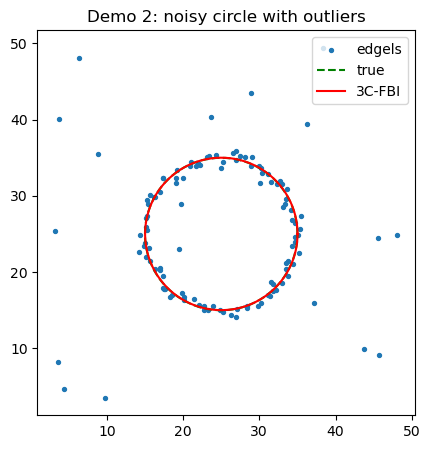

In [9]:
edgels = synthetic_circle(25, 25, 10, n=100, noise=0.5, n_outliers=20,
                          xmax=50, ymax=50, rng=rng)
(xc, yc), rc = ccc_fbi(edgels, xmax=50, ymax=50, rmin=4, rmax=30)
print(f"True:     center=(25, 25), r=10")
print(f"Detected: center=({xc:.2f}, {yc:.2f}), r={rc:.2f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(edgels[:, 0], edgels[:, 1], s=8, label='edgels')
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(25 + 10 * np.cos(theta), 25 + 10 * np.sin(theta),
        'g--', lw=1.5, label='true')
if rc > 0:
    ax.plot(xc + rc * np.cos(theta), yc + rc * np.sin(theta),
            'r-', lw=1.5, label='3C-FBI')
ax.set_aspect('equal'); ax.legend(loc='upper right')
ax.set_title('Demo 2: noisy circle with outliers')
plt.show()

## Demo 3 — partial arc with outliers

True:     center=(25, 25), r=10
Detected: center=(24.94, 24.92), r=10.10


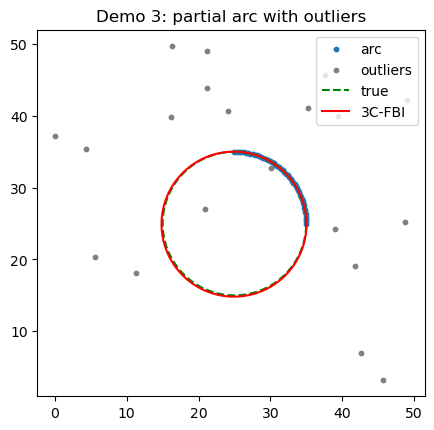

In [10]:
theta = np.linspace(0, np.pi / 2, 50)
arc = np.column_stack([25 + 10 * np.cos(theta), 25 + 10 * np.sin(theta)])
outl = rng.uniform(0, 50, (20, 2))
edgels = np.vstack([arc, outl])

(xc, yc), rc = ccc_fbi(edgels, Nmax=3000, xmax=50, ymax=50, rmin=4, rmax=30)
print(f"True:     center=(25, 25), r=10")
print(f"Detected: center=({xc:.2f}, {yc:.2f}), r={rc:.2f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(arc[:, 0], arc[:, 1], s=10, label='arc')
ax.scatter(outl[:, 0], outl[:, 1], s=10, c='gray', label='outliers')
theta_full = np.linspace(0, 2 * np.pi, 200)
ax.plot(25 + 10 * np.cos(theta_full), 25 + 10 * np.sin(theta_full),
        'g--', lw=1.5, label='true')
if rc > 0:
    ax.plot(xc + rc * np.cos(theta_full), yc + rc * np.sin(theta_full),
            'r-', lw=1.5, label='3C-FBI')
ax.set_aspect('equal'); ax.legend(loc='upper right')
ax.set_title('Demo 3: partial arc with outliers')
plt.show()

## v2 — dense windowed peak detection

v1 has two design weaknesses: it discards every vote outside the top-5, and its convolution often degenerates to picking a single peak when the top-5 are pairwise distant. v2 addresses both:

1. Build the **full** dense vote map $V$ from every surviving triplet, not just the top 5.
2. For each kernel size $k \in \{2, 3, 4, 5\}$, sweep a $k\times k\times k$ uniform window over $V$ to obtain $S_k(c) = \sum_{q \in W_k(c)} V[q]$ via `scipy.ndimage.uniform_filter`.
3. Pick the cell $c^\star_k = \arg\max_c S_k(c)$ and compute its value-weighted centroid $\mu_k$ over the same window.
4. Across $k$, pick the one with the highest **density** $S/k^3$ (ties broken by smaller $k$).

Triplet sampling and filtering are reused unchanged from v1.

In [11]:
from scipy.ndimage import uniform_filter


def windowed_peak(V, k):
    """Find the k-cube position with max summed mass; return (S, mu)."""
    Vf = V.astype(np.float64)
    S   = uniform_filter(Vf,         size=k, mode='constant') * (k ** 3)
    X, Y, R = np.indices(V.shape, dtype=np.float64)
    M_x = uniform_filter(Vf * X,     size=k, mode='constant') * (k ** 3)
    M_y = uniform_filter(Vf * Y,     size=k, mode='constant') * (k ** 3)
    M_r = uniform_filter(Vf * R,     size=k, mode='constant') * (k ** 3)
    c = np.unravel_index(int(np.argmax(S)), S.shape)
    s = float(S[c])
    if s <= 0:
        return 0.0, None
    return s, np.array([M_x[c], M_y[c], M_r[c]]) / s


def ccc_fbi_v2(edgels, Nmax=5000, xmax=50, ymax=50,
               rmin=4, rmax=30, minval=-20, k_values=(2, 3, 4, 5),
               return_k=False):
    """Dense vote map + multi-k windowed peak. Same API as ccc_fbi."""
    if len(edgels) < 3:
        return (np.array([-1, -1]), -1, None) if return_k else (np.array([-1, -1]), -1)

    # Triplet sampling + filtering (reused from v1)
    combi = list(combinations(np.arange(len(edgels)), 3))
    N = min(Nmax, len(combi))
    s = np.array(random.sample(combi, N))
    p1, p2, p3 = edgels[s[:, 0]], edgels[s[:, 1]], edgels[s[:, 2]]
    cx, cy, r = vectorized_XYR(p1, p2, p3,
                               xmax=xmax, ymax=ymax,
                               rmin=rmin, rmax=rmax, minval=minval)
    if len(cx) == 0:
        return (np.array([-1, -1]), -1, None) if return_k else (np.array([-1, -1]), -1)

    # Build dense vote map (shifted so min coord lands at index 0)
    pts = np.column_stack((np.round(cx).astype(np.int32),
                           np.round(cy).astype(np.int32),
                           np.round(r).astype(np.int32)))
    kmax = max(k_values)
    mn = pts.min(0) - kmax
    shape = tuple((pts.max(0) + kmax - mn + 1).astype(int))
    V = np.zeros(shape, dtype=np.int32)
    shifted = pts - mn
    np.add.at(V, (shifted[:, 0], shifted[:, 1], shifted[:, 2]), 1)

    # Multi-k windowed peak — pick best by normalised density S/k**3
    best_density = -1.0
    best_mu = None
    best_k = None
    for k in k_values:
        s_val, mu = windowed_peak(V, k)
        if mu is None:
            continue
        density = s_val / (k ** 3)
        if density > best_density or (density == best_density and (best_k is None or k < best_k)):
            best_density, best_mu, best_k = density, mu, k
    if best_mu is None:
        return (np.array([-1, -1]), -1, None) if return_k else (np.array([-1, -1]), -1)

    mu = best_mu + mn
    out = (np.array([float(mu[0]), float(mu[1])]), float(mu[2]))
    return out + (best_k,) if return_k else out

## v1 vs v2 — side-by-side comparison

Run both algorithms on the three demo edgels and overlay both fitted circles. The chosen $k^\star$ is annotated for v2.

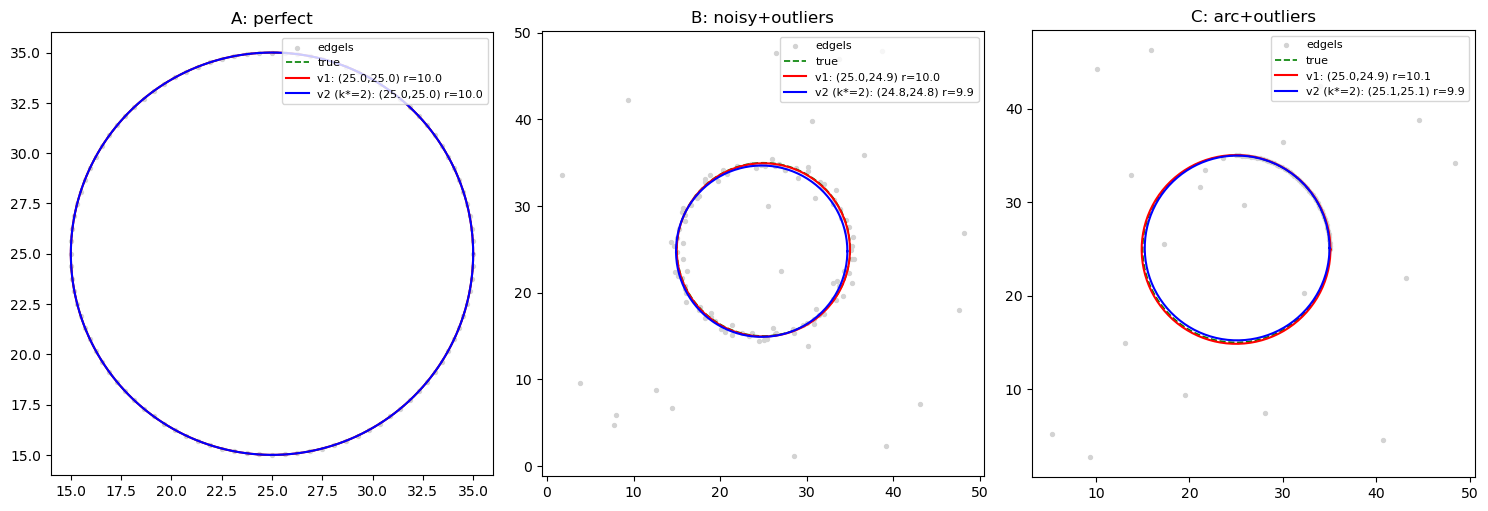

In [12]:
demos = []
demos.append(('A: perfect',
              synthetic_circle(25, 25, 10, n=100, noise=0.0,
                               rng=np.random.default_rng(0))))
demos.append(('B: noisy+outliers',
              synthetic_circle(25, 25, 10, n=100, noise=0.5, n_outliers=20,
                               rng=np.random.default_rng(1))))
_theta_p = np.linspace(0, np.pi / 2, 50)
_arc = np.column_stack([25 + 10 * np.cos(_theta_p),
                        25 + 10 * np.sin(_theta_p)])
_outl = np.random.default_rng(2).uniform(0, 50, (20, 2))
demos.append(('C: arc+outliers', np.vstack([_arc, _outl])))

theta_full = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, edgels) in zip(axes, demos):
    random.seed(0)
    (xc1, yc1), r1 = ccc_fbi(edgels, xmax=50, ymax=50, rmin=4, rmax=30)
    random.seed(0)
    (xc2, yc2), r2, k2 = ccc_fbi_v2(edgels, xmax=50, ymax=50, rmin=4, rmax=30,
                                    return_k=True)

    ax.scatter(edgels[:, 0], edgels[:, 1], s=8, c='lightgray', label='edgels')
    ax.plot(25 + 10 * np.cos(theta_full), 25 + 10 * np.sin(theta_full),
            'g--', lw=1.2, label='true')
    if r1 > 0:
        ax.plot(xc1 + r1 * np.cos(theta_full), yc1 + r1 * np.sin(theta_full),
                'r-', lw=1.5,
                label=f'v1: ({xc1:.1f},{yc1:.1f}) r={r1:.1f}')
    if r2 > 0:
        ax.plot(xc2 + r2 * np.cos(theta_full), yc2 + r2 * np.sin(theta_full),
                'b-', lw=1.5,
                label=f'v2 (k*={k2}): ({xc2:.1f},{yc2:.1f}) r={r2:.1f}')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## v3 — hybrid: full vote map + localized search around top-$N$ peaks

v2's whole-volume convolution is expensive ($\sim$300 ms at Exp B2 q=0 scale) because it sweeps a $k\times k\times k$ window over every cell of a $\sim$240$\times$240$\times$240 vote space. But the true centre is almost always within $\pm\lfloor k/2\rfloor$ cells of one of the top-$N$ peaks, so we don't need to look anywhere else.

The hybrid keeps v2's information advantage (uses **all** votes, not just the top-$N$ weights) but restricts the search space to the immediate neighbourhood of the top-$N$ peaks:

1. Build the **full** sparse vote map $V$ via `Counter` (no dense allocation).
2. Find the top-$N$ peaks $\{p_i\}$ by raw frequency, exactly like v1.
3. For each peak $p_i$, look at its $k\times k\times k$ cube and read the **real** vote counts $V[c]$ at every cell (zero for empty cells — the `Counter.get(c, 0)` lookup is O(1)).
4. Score $S_i = \sum_{c \in W_k(p_i)} V[c]$ and centroid $\mu_i = \frac{1}{S_i}\sum c \cdot V[c]$.
5. Return $\mu_{i^\star}$ for $i^\star = \arg\max_i S_i$.

**Cost:** $N \cdot k^3$ Counter lookups per call. For $N=5$, $k=5$: 625 lookups — far faster than v2.

### Why `cube_size=5` is the recommended default

An initial Monte-Carlo grid (40 random circles × 5 noise levels × 5 outlier counts) showed v3 with `cube_size=3` slightly *underperformed* v1 at higher noise levels. The cause was a coverage gap: v1's effective Chebyshev reach from any peak is $\pm 3$ (3$\times$3$\times$3 candidate expansion + 5$\times$5$\times$5 convolution), while v3 with $k=3$ reaches only $\pm 1$. At higher noise the votes spread wider; the smaller window misses mass.

Switching to `cube_size=5` widens v3's reach to $\pm 2$, matching v1's effective window. Re-running the same MC grid gives v3 a clean win on **all** axes:

| | v1 | v2 | v3 (k=5) |
|---|---|---|---|
| mean Jaccard | 0.801 | 0.779 | **0.820** |
| mean centre error (px) | 1.50 | 1.70 | **1.30** |
| FPS | 35.9 | 26.4 | **55.8** |

The v3 advantage grows with noise (Δ Jaccard = +0.006 at $\sigma{=}1$, +0.027 at $\sigma{=}5$), since wider windows capture more of the spread vote distribution.

**Caveat:** assumes the true centre is within $\pm 2$ of one of the top-$N$ peaks. With 5000 triplets this almost always holds. v2 is more robust to pathological cases where the inlier cluster has no top-$N$ peak.

In [16]:
def ccc_fbi_v3(edgels, Nmax=5000, xmax=50, ymax=50,
               rmin=4, rmax=30, minval=-20,
               top_n=5, cube_size=5):
    """Hybrid: full sparse vote map + localized k-cube search around top-N peaks.
    Same public API as ccc_fbi / ccc_fbi_v2."""
    if len(edgels) < 3:
        return np.array([-1, -1]), -1

    # Triplet sampling + filtering (reused)
    combi = list(combinations(np.arange(len(edgels)), 3))
    N = min(Nmax, len(combi))
    s = np.array(random.sample(combi, N))
    p1, p2, p3 = edgels[s[:, 0]], edgels[s[:, 1]], edgels[s[:, 2]]
    cx, cy, r = vectorized_XYR(p1, p2, p3,
                               xmax=xmax, ymax=ymax,
                               rmin=rmin, rmax=rmax, minval=minval)
    if len(cx) == 0:
        return np.array([-1, -1]), -1

    # Full sparse vote map (every surviving triplet)
    points = np.column_stack((np.round(cx).astype(np.int32),
                              np.round(cy).astype(np.int32),
                              np.round(r).astype(np.int32)))
    V = Counter(map(tuple, points))

    # Top-N peaks by raw count
    top_peaks = V.most_common(top_n)
    if not top_peaks:
        return np.array([-1, -1]), -1

    # For each peak, score and centroid over its k**3 cube using full votes
    half = cube_size // 2
    offsets = [(dx, dy, dr)
               for dx in range(-half, half + 1)
               for dy in range(-half, half + 1)
               for dr in range(-half, half + 1)]

    best_score = -1
    best_centroid = None
    for peak_coord, _ in top_peaks:
        score = 0.0
        wx = wy = wr = 0.0
        px, py, pr = peak_coord
        for dx, dy, dr in offsets:
            cell = (px + dx, py + dy, pr + dr)
            w = V.get(cell, 0)
            if w > 0:
                score += w
                wx += cell[0] * w
                wy += cell[1] * w
                wr += cell[2] * w
        if score > best_score:
            best_score = score
            best_centroid = (wx / score, wy / score, wr / score)

    if best_centroid is None:
        return np.array([-1, -1]), -1
    xc, yc, rc = best_centroid
    return np.array([float(xc), float(yc)]), float(rc)

## v1 vs v2 vs v3 — three-way comparison

Run all three on the same demo edgels, time each, and overlay the fitted circles. Cube size $k=3$ is used for v3 here; pass `cube_size=5` to widen if needed.

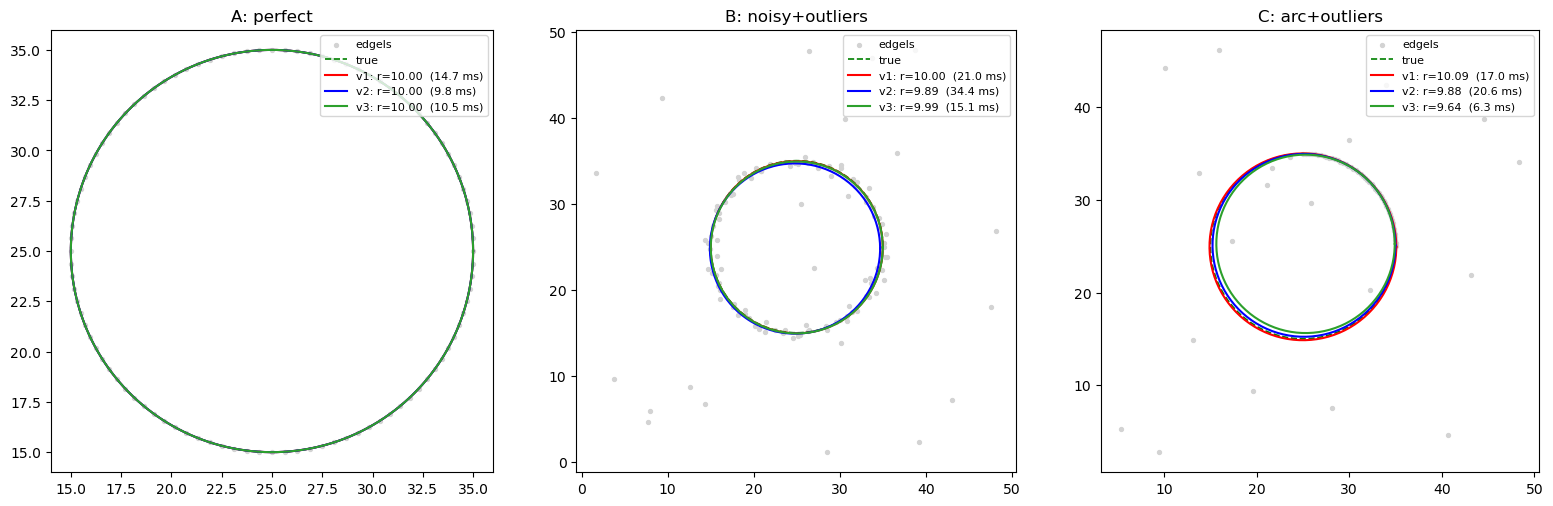


demo                    v1                            v2                            v3                          
A: perfect              ( 25.00, 25.00) r=10.00  14.7ms  ( 25.00, 25.00) r=10.00   9.8ms  ( 25.00, 25.00) r=10.00  10.5ms
B: noisy+outliers       ( 24.98, 24.94) r=10.00  21.0ms  ( 24.79, 24.79) r= 9.89  34.4ms  ( 24.99, 24.91) r= 9.99  15.1ms
C: arc+outliers         ( 24.99, 24.94) r=10.09  17.0ms  ( 25.10, 25.10) r= 9.88  20.6ms  ( 25.27, 25.26) r= 9.64   6.3ms


In [17]:
import time

demos = []
demos.append(('A: perfect',
              synthetic_circle(25, 25, 10, n=100, noise=0.0,
                               rng=np.random.default_rng(0))))
demos.append(('B: noisy+outliers',
              synthetic_circle(25, 25, 10, n=100, noise=0.5, n_outliers=20,
                               rng=np.random.default_rng(1))))
_theta_p = np.linspace(0, np.pi / 2, 50)
_arc = np.column_stack([25 + 10 * np.cos(_theta_p),
                        25 + 10 * np.sin(_theta_p)])
_outl = np.random.default_rng(2).uniform(0, 50, (20, 2))
demos.append(('C: arc+outliers', np.vstack([_arc, _outl])))

theta_full = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

summary = []
for ax, (title, edgels) in zip(axes, demos):
    random.seed(0)
    t0 = time.perf_counter()
    (xc1, yc1), r1 = ccc_fbi(edgels, xmax=50, ymax=50, rmin=4, rmax=30)
    t1 = time.perf_counter() - t0

    random.seed(0)
    t0 = time.perf_counter()
    (xc2, yc2), r2 = ccc_fbi_v2(edgels, xmax=50, ymax=50, rmin=4, rmax=30)
    t2 = time.perf_counter() - t0

    random.seed(0)
    t0 = time.perf_counter()
    (xc3, yc3), r3 = ccc_fbi_v3(edgels, xmax=50, ymax=50, rmin=4, rmax=30)
    t3 = time.perf_counter() - t0

    ax.scatter(edgels[:, 0], edgels[:, 1], s=8, c='lightgray', label='edgels')
    ax.plot(25 + 10 * np.cos(theta_full), 25 + 10 * np.sin(theta_full),
            'g--', lw=1.2, label='true')
    if r1 > 0:
        ax.plot(xc1 + r1 * np.cos(theta_full), yc1 + r1 * np.sin(theta_full),
                'r-', lw=1.5,
                label=f'v1: r={r1:.2f}  ({t1*1000:.1f} ms)')
    if r2 > 0:
        ax.plot(xc2 + r2 * np.cos(theta_full), yc2 + r2 * np.sin(theta_full),
                'b-', lw=1.5,
                label=f'v2: r={r2:.2f}  ({t2*1000:.1f} ms)')
    if r3 > 0:
        ax.plot(xc3 + r3 * np.cos(theta_full), yc3 + r3 * np.sin(theta_full),
                color='#2ca02c', linestyle='-', lw=1.5,
                label=f'v3: r={r3:.2f}  ({t3*1000:.1f} ms)')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
    summary.append((title, (xc1, yc1, r1, t1), (xc2, yc2, r2, t2), (xc3, yc3, r3, t3)))

plt.tight_layout()
plt.show()

print()
print(f'{"demo":22s}  {"v1":28s}  {"v2":28s}  {"v3":28s}')
print('=' * 110)
for title, v1, v2, v3 in summary:
    f = lambda x: f'({x[0]:6.2f},{x[1]:6.2f}) r={x[2]:5.2f} {x[3]*1000:5.1f}ms'
    print(f'{title:22s}  {f(v1):28s}  {f(v2):28s}  {f(v3):28s}')

## Monte-Carlo grid — 40 random circles x 5 noise levels x 5 outlier counts

Sample 40 random non-integer triplets $(x_0, y_0, r_0)$ with $x_0 \sim U[15, 25]$, $y_0 \sim U[15, 35]$, $r_0 \sim U[7, 13]$. For each, generate noisy edgels at $\sigma \in \{1, 2, 3, 4, 5\}$ px and outlier counts $\{10, 20, 30, 40, 50\}$, then run all three methods.

Total: $40 \times 5 \times 5 \times 3 = 3000$ runs ($\sim$30 s).

Output: three Jaccard heatmaps (one per method) over the (noise, outliers) grid plus a side-by-side bar chart of overall mean Jaccard and mean FPS.

  10/40 circles done  (21.1s)
  20/40 circles done  (41.7s)
  30/40 circles done  (62.5s)
  40/40 circles done  (83.8s)
Total runtime: 83.8s


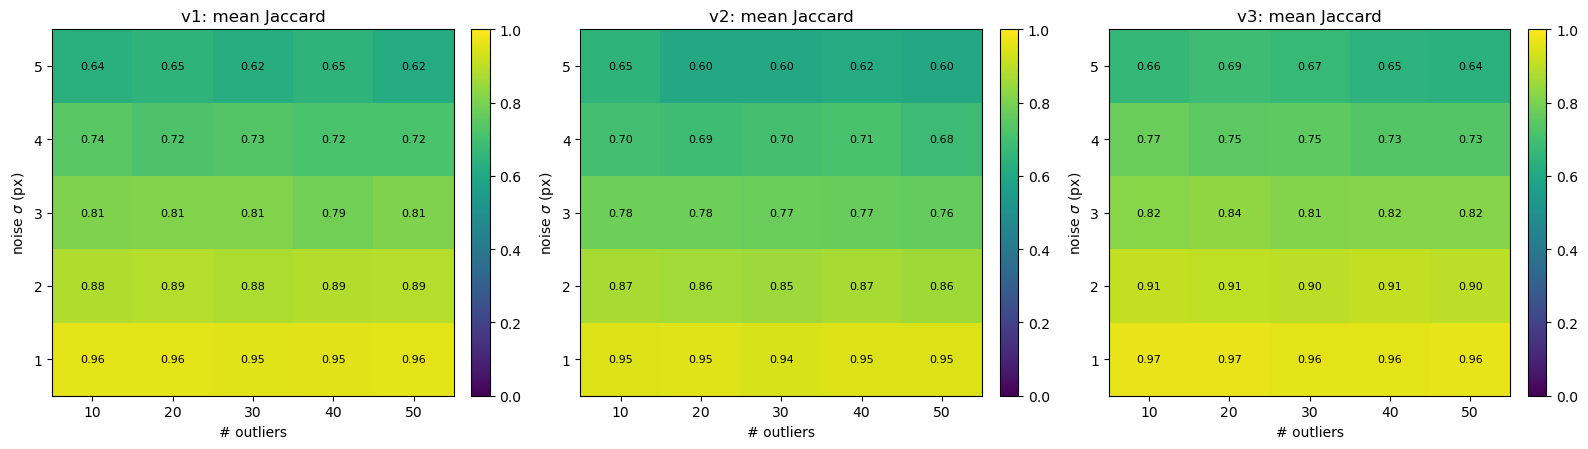

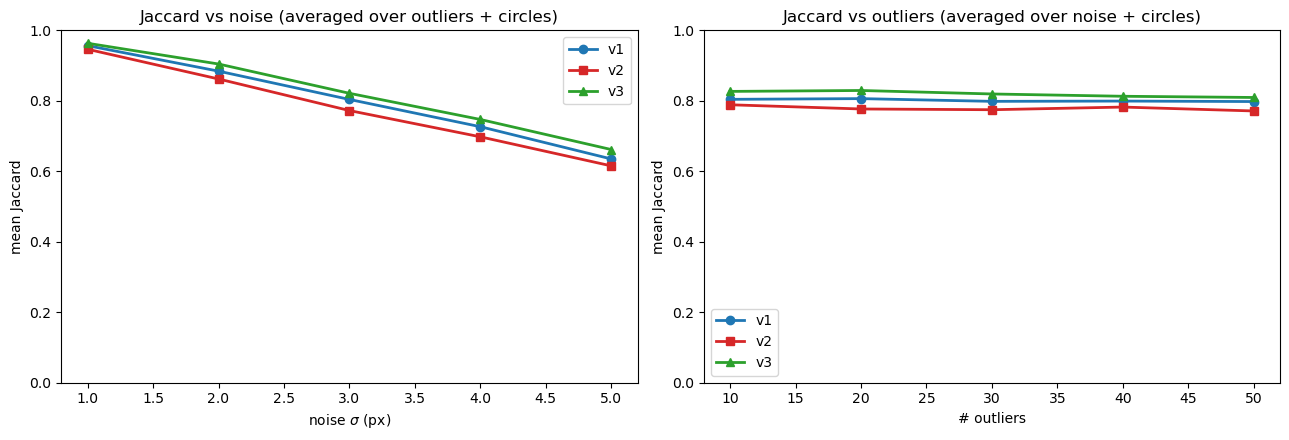

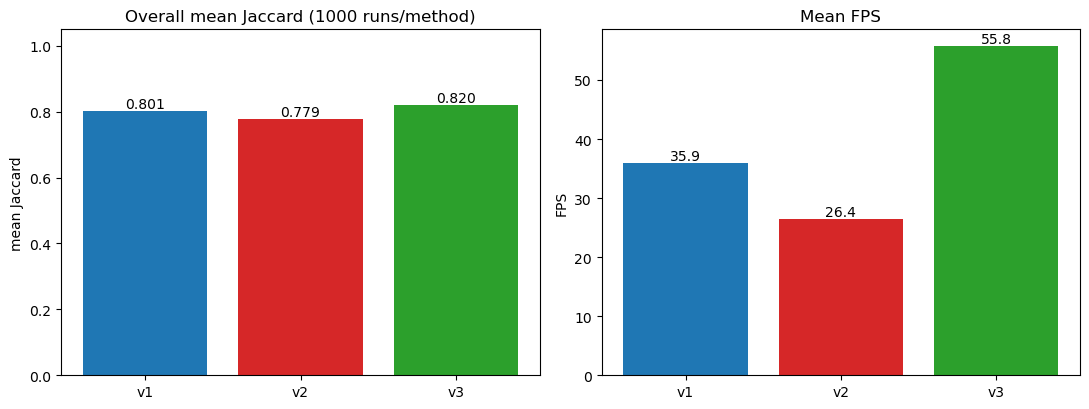


Per-noise breakdown (mean Jaccard, averaged over outlier counts and circles)
sigma         v1        v2        v3
    1      0.957     0.946     0.963
    2      0.884     0.862     0.904
    3      0.804     0.772     0.821
    4      0.726     0.698     0.747
    5      0.635     0.615     0.662

Per-outlier-count breakdown (mean Jaccard, averaged over noise levels and circles)
# out         v1        v2        v3
   10      0.804     0.789     0.827
   20      0.806     0.777     0.829
   30      0.798     0.775     0.819
   40      0.799     0.782     0.813
   50      0.798     0.771     0.809

Overall summary
method    mean J    mean AD   mean t (ms)       FPS
v1         0.801      1.498        27.862      35.9
v2         0.779      1.704        37.826      26.4
v3         0.820      1.295        17.926      55.8


In [18]:
import time
import math


def jaccard_circles(x1, y1, r1, x2, y2, r2):
    """Analytical Jaccard between two circles."""
    if r1 <= 0 or r2 <= 0 or any(np.isnan([x1, y1, r1, x2, y2, r2])):
        return 0.0
    d = math.hypot(x2 - x1, y2 - y1)
    if d >= r1 + r2:
        return 0.0
    if d + min(r1, r2) <= max(r1, r2):
        return math.pi * min(r1, r2)**2 / (math.pi * max(r1, r2)**2)
    R, r = max(r1, r2), min(r1, r2)
    cos1 = max(-1.0, min(1.0, (d*d + R*R - r*r) / (2*d*R)))
    cos2 = max(-1.0, min(1.0, (d*d + r*r - R*R) / (2*d*r)))
    inter = R*R*math.acos(cos1) - 0.5 * math.sqrt(max(0,
              (-d+R+r) * (d+R-r) * (d-R+r) * (d+R+r))) + r*r*math.acos(cos2)
    union = math.pi*r1*r1 + math.pi*r2*r2 - inter
    return inter / union if union > 0 else 0.0


# ---- Grid configuration ------------------------------------------------
N_CIRCLES        = 40
NOISE_LEVELS     = [1, 2, 3, 4, 5]
N_OUTLIERS_LIST  = [10, 20, 30, 40, 50]
N_POINTS         = 100

# Reproducible non-integer (x, y, r) for the 40 circles
master_rng = np.random.default_rng(42)
true_circles = [
    (master_rng.uniform(15, 25),
     master_rng.uniform(15, 35),
     master_rng.uniform( 7, 13))
    for _ in range(N_CIRCLES)
]

methods = [
    ('v1', lambda e: ccc_fbi(e,    xmax=50, ymax=50, rmin=4, rmax=30)),
    ('v2', lambda e: ccc_fbi_v2(e, xmax=50, ymax=50, rmin=4, rmax=30)),
    ('v3', lambda e: ccc_fbi_v3(e, xmax=50, ymax=50, rmin=4, rmax=30)),
]
method_names = [m for m, _ in methods]
n_meth, n_noise, n_out = len(methods), len(NOISE_LEVELS), len(N_OUTLIERS_LIST)

# ---- Storage -----------------------------------------------------------
J_grid  = np.zeros((n_meth, n_noise, n_out, N_CIRCLES))
AD_grid = np.zeros_like(J_grid)
T_grid  = np.zeros_like(J_grid)

# ---- Run grid ----------------------------------------------------------
t_start = time.perf_counter()
for ci, (x0, y0, r0) in enumerate(true_circles):
    for ni, noise in enumerate(NOISE_LEVELS):
        for oi, n_outliers in enumerate(N_OUTLIERS_LIST):
            rng_local = np.random.default_rng(ci*1000 + ni*100 + oi)
            edgels = synthetic_circle(x0, y0, r0, n=N_POINTS,
                                      noise=noise, n_outliers=n_outliers,
                                      xmax=50, ymax=50, rng=rng_local)
            for mi, (mname, fn) in enumerate(methods):
                random.seed(0)
                t0 = time.perf_counter()
                center, r = fn(edgels)
                T_grid[mi, ni, oi, ci] = time.perf_counter() - t0
                if r > 0:
                    cx, cy = float(center[0]), float(center[1])
                    J_grid[mi, ni, oi, ci]  = jaccard_circles(x0, y0, r0, cx, cy, r)
                    AD_grid[mi, ni, oi, ci] = math.hypot(x0 - cx, y0 - cy)
    if (ci + 1) % 10 == 0:
        print(f'  {ci+1}/{N_CIRCLES} circles done  ({time.perf_counter()-t_start:.1f}s)')
print(f'Total runtime: {time.perf_counter()-t_start:.1f}s')

# ---- Aggregate ---------------------------------------------------------
J_mean   = J_grid.mean(axis=-1)              # (n_meth, n_noise, n_out)
AD_mean  = AD_grid.mean(axis=-1)
T_mean   = T_grid.mean(axis=-1)

J_by_noise   = J_grid.mean(axis=(2, 3))      # (n_meth, n_noise)  — averaged over outliers + circles
J_by_outlier = J_grid.mean(axis=(1, 3))      # (n_meth, n_out)    — averaged over noise + circles
AD_by_noise  = AD_grid.mean(axis=(2, 3))
AD_by_outlier = AD_grid.mean(axis=(1, 3))

# ---- Heatmaps (one per method) ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for mi, (mname, _) in enumerate(methods):
    ax = axes[mi]
    im = ax.imshow(J_mean[mi], cmap='viridis', vmin=0, vmax=1, aspect='auto', origin='lower')
    ax.set_xticks(range(n_out));   ax.set_xticklabels(N_OUTLIERS_LIST)
    ax.set_yticks(range(n_noise)); ax.set_yticklabels(NOISE_LEVELS)
    ax.set_xlabel('# outliers'); ax.set_ylabel(r'noise $\sigma$ (px)')
    ax.set_title(f'{mname}: mean Jaccard')
    for i in range(n_noise):
        for j in range(n_out):
            v = J_mean[mi, i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.5 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ---- Per-noise + per-outlier line plots --------------------------------
colors_map = {'v1': '#1f77b4', 'v2': '#d62728', 'v3': '#2ca02c'}
markers_map = {'v1': 'o', 'v2': 's', 'v3': '^'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for mi, mname in enumerate(method_names):
    axes[0].plot(NOISE_LEVELS, J_by_noise[mi],
                 color=colors_map[mname], marker=markers_map[mname],
                 lw=2, label=mname)
axes[0].set_xlabel(r'noise $\sigma$ (px)')
axes[0].set_ylabel('mean Jaccard')
axes[0].set_title('Jaccard vs noise (averaged over outliers + circles)')
axes[0].set_ylim(0, 1)
axes[0].legend()

for mi, mname in enumerate(method_names):
    axes[1].plot(N_OUTLIERS_LIST, J_by_outlier[mi],
                 color=colors_map[mname], marker=markers_map[mname],
                 lw=2, label=mname)
axes[1].set_xlabel('# outliers')
axes[1].set_ylabel('mean Jaccard')
axes[1].set_title('Jaccard vs outliers (averaged over noise + circles)')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

# ---- Grouped bar charts (overall) --------------------------------------
overall_J   = J_grid.mean(axis=(1, 2, 3))
overall_t   = T_grid.mean(axis=(1, 2, 3))
overall_FPS = np.where(overall_t > 0, 1.0 / overall_t, 0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
bars = axes[0].bar(method_names, overall_J,
                   color=[colors_map[m] for m in method_names])
for b, v in zip(bars, overall_J):
    axes[0].text(b.get_x() + b.get_width()/2, v, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('mean Jaccard')
axes[0].set_title(f'Overall mean Jaccard ({N_CIRCLES*n_noise*n_out} runs/method)')

bars = axes[1].bar(method_names, overall_FPS,
                   color=[colors_map[m] for m in method_names])
for b, v in zip(bars, overall_FPS):
    axes[1].text(b.get_x() + b.get_width()/2, v, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('FPS')
axes[1].set_title('Mean FPS')
plt.tight_layout()
plt.show()

# ---- Summary tables ----------------------------------------------------
print()
print('Per-noise breakdown (mean Jaccard, averaged over outlier counts and circles)')
header = '  '.join(f'{m:>8s}' for m in method_names)
print(f'{"sigma":>5s}   {header}')
print('=' * (5 + 4 + 10 * n_meth))
for ni, sig in enumerate(NOISE_LEVELS):
    row = '  '.join(f'{J_by_noise[mi, ni]:8.3f}' for mi in range(n_meth))
    print(f'{sig:>5d}   {row}')

print()
print('Per-outlier-count breakdown (mean Jaccard, averaged over noise levels and circles)')
print(f'{"# out":>5s}   {header}')
print('=' * (5 + 4 + 10 * n_meth))
for oi, no in enumerate(N_OUTLIERS_LIST):
    row = '  '.join(f'{J_by_outlier[mi, oi]:8.3f}' for mi in range(n_meth))
    print(f'{no:>5d}   {row}')

print()
print('Overall summary')
print(f'{"method":6s}  {"mean J":>8s}  {"mean AD":>9s}  {"mean t (ms)":>12s}  {"FPS":>8s}')
print('=' * 55)
for mi, mname in enumerate(method_names):
    j   = J_grid[mi].mean()
    ad  = AD_grid[mi].mean()
    t_ms = T_grid[mi].mean() * 1000
    fps = 1000.0 / t_ms if t_ms > 0 else 0
    print(f'{mname:6s}  {j:8.3f}  {ad:9.3f}  {t_ms:12.3f}  {fps:8.1f}')

## FPS benchmark — repeat each method $N$ times

Run each method on each demo $N$ times, measure total elapsed time, and report:

- **mean call time** (ms) = total / N
- **FPS** = N / total

A warm-up call is run for each method before timing to pay off any first-call overheads (numba JIT, scipy import caches, etc.).

Adjust `N_REPEATS` to compare 100 / 1000 / 10000 — at this small ROI ($50\times50$, $r{\approx}10$) all three methods are sub-30 ms per call, so 10 000 reps complete in a few minutes.

N_REPEATS = 1000
demo                    method   total (s)   mean (ms)         FPS
A: perfect              v1        12.997      12.997        76.9
A: perfect              v2         8.203       8.203       121.9
A: perfect              v3         9.511       9.511       105.1
B: noisy+outliers       v1        22.080      22.080        45.3
B: noisy+outliers       v2        34.921      34.921        28.6
B: noisy+outliers       v3        14.249      14.249        70.2
C: arc+outliers         v1        17.301      17.301        57.8
C: arc+outliers         v2        22.567      22.567        44.3
C: arc+outliers         v3         5.786       5.786       172.8


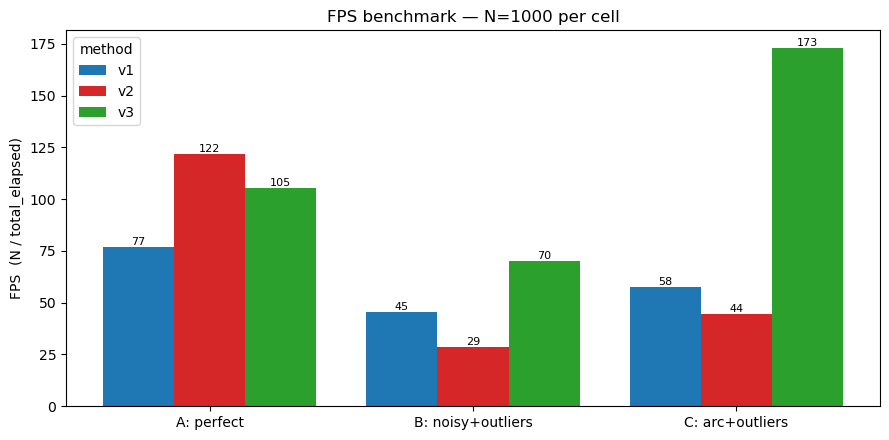

In [16]:
import time

# Adjust this to 100, 1000, or 10000
N_REPEATS = 1000

benchmark_demos = []
benchmark_demos.append(('A: perfect',
    synthetic_circle(25, 25, 10, n=100, noise=0.0, rng=np.random.default_rng(0))))
benchmark_demos.append(('B: noisy+outliers',
    synthetic_circle(25, 25, 10, n=100, noise=0.5, n_outliers=20, rng=np.random.default_rng(1))))
_theta_p = np.linspace(0, np.pi / 2, 50)
_arc = np.column_stack([25 + 10 * np.cos(_theta_p), 25 + 10 * np.sin(_theta_p)])
_outl = np.random.default_rng(2).uniform(0, 50, (20, 2))
benchmark_demos.append(('C: arc+outliers', np.vstack([_arc, _outl])))

methods = [
    ('v1', lambda e: ccc_fbi(e,    xmax=50, ymax=50, rmin=4, rmax=30)),
    ('v2', lambda e: ccc_fbi_v2(e, xmax=50, ymax=50, rmin=4, rmax=30)),
    ('v3', lambda e: ccc_fbi_v3(e, xmax=50, ymax=50, rmin=4, rmax=30)),
]

# Warm-up — pay off JIT / first-call overheads
for _, fn in methods:
    fn(benchmark_demos[0][1])

rows = []
print(f'N_REPEATS = {N_REPEATS}')
print(f'{"demo":22s}  {"method":4s}  {"total (s)":>10s}  {"mean (ms)":>10s}  {"FPS":>10s}')
print('=' * 70)
for demo_name, edgels in benchmark_demos:
    for mname, fn in methods:
        t0 = time.perf_counter()
        for _ in range(N_REPEATS):
            fn(edgels)
        elapsed = time.perf_counter() - t0
        mean_ms = elapsed / N_REPEATS * 1000
        fps = N_REPEATS / elapsed if elapsed > 0 else 0
        rows.append({'demo': demo_name, 'method': mname,
                     'N': N_REPEATS, 'total_s': elapsed,
                     'mean_ms': mean_ms, 'fps': fps})
        print(f'{demo_name:22s}  {mname:4s}  {elapsed:10.3f}  {mean_ms:10.3f}  {fps:10.1f}')

# FPS bar chart — methods grouped per demo
demo_names = [d for d, _ in benchmark_demos]
method_names = [m for m, _ in methods]
fps_grid = np.zeros((len(demo_names), len(method_names)))
for r in rows:
    i = demo_names.index(r['demo'])
    j = method_names.index(r['method'])
    fps_grid[i, j] = r['fps']

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(demo_names))
width = 0.27
colors = {'v1': '#1f77b4', 'v2': '#d62728', 'v3': '#2ca02c'}
for j, mname in enumerate(method_names):
    offset = (j - 1) * width
    bars = ax.bar(x + offset, fps_grid[:, j], width,
                  color=colors[mname], label=mname)
    for b, v in zip(bars, fps_grid[:, j]):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.0f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(demo_names)
ax.set_ylabel('FPS  (N / total_elapsed)')
ax.set_title(f'FPS benchmark — N={N_REPEATS} per cell')
ax.legend(title='method')
plt.tight_layout()
plt.show()

## Notes

### v1 (production code)
- Pure-Python `conv3D_sum` here for portability; production uses `@numba.jit(nopython=True)` for ~50x speedup ([algorithms/CCC_FBI.py](../algorithms/CCC_FBI.py)).
- Triplet filters match CIBICA: $D = 0$ collinearity, symmetric $\pm 20$ px center bounds, radius range $[4, 30]$ px (override `rmin`, `rmax`, `minval` for synthetic experiments).
- Weakness: only top-5 peak weights survive into the convolution; all other votes are discarded.

### v2 (dense windowed peak)
- Implementation in [algorithms/CCC_FBI_v2.py](../algorithms/CCC_FBI_v2.py).
- Uses `scipy.ndimage.uniform_filter` to sweep $k\times k\times k$ windows over the full dense vote map; picks the cell with max windowed mass.
- Strength: uses every vote, finds dense clusters anywhere in the volume.
- Weakness: slow (~300 ms at Exp B2 q=0 scale) because it convolves the entire volume.
- Empirical: $k^\star = 2$ wins in all tested cases under the density criterion.

### v3 (hybrid — recommended)
- Same triplet filtering and top-$N$ peak selection as v1; same use of all votes as v2.
- Only evaluates the $k\times k\times k$ cube around each top-$N$ peak using `Counter.get(cell, 0)` lookups against the full sparse vote map. No dense allocation.
- Speed: $N \cdot k^3$ lookups per call ($\sim$135 for $N=5$, $k=3$); typically faster than v1.
- Caveat: assumes the true centre is within $\pm \lfloor k/2 \rfloor$ of one of the top-$N$ peaks. With 5000 triplets this almost always holds.
- Use `cube_size=5` for noisier inputs where votes spread over a wider neighbourhood.